# DPP-aware Portfolio Optimization with CVXPY — A Tutorial

*A hands-on walkthrough of Disciplined Parametrized Programming in CVXPY,
using mean-variance portfolio construction as the motivating example.*

**Who this is for.** Anyone who has written a CVXPY problem inside a
for-loop (backtesting, daily rebalancing, parameter sweeps, scenario
analysis) and wondered why it is slower than it should be.

**What you will learn.**

1. Why the "rebuild the `cp.Problem` every iteration" pattern is slow, and
   how wrapping changing inputs in `cp.Parameter` lets CVXPY's DPP machinery
   cache the problem structure and skip canonicalization on re-solves.
2. Why `cp.quad_form(w, Sigma_param)` is **not** DPP-compliant — even
   though it compiles and solves — and how a Cholesky reformulation using
   `cp.sum_squares` sidesteps the issue without changing the math.
3. That raw speedup is not the point. The real value of DPP is faster
   *research iteration*: a 250-day walk-forward backtest that used to take
   minutes now takes seconds, which is the difference between "try one
   idea a day" and "try twenty before lunch". Section 9 runs that backtest
   on real market data and shows a sensible, diversified optimizer
   portfolio that beats the equal-weight benchmark on every risk-adjusted
   metric.

The notebook is intentionally self-contained: you can read it end to end
without jumping to the package source. The matching script
[`portfolio_optimization_dpp.py`](./portfolio_optimization_dpp.py) contains
the same code in one file for command-line execution and CI.

## 0. Setup

In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

print("cvxpy", cp.__version__)
print("numpy", np.__version__)
print("pandas", pd.__version__)

cvxpy 1.8.2
numpy 2.4.3
pandas 2.3.3


## 1. Data pipeline

[yfinance](https://github.com/ranaroussi/yfinance) knows
how to fetch and align historical Close prices for a basket of tickers,
handle yfinance's MultiIndex quirks, and return a clean DataFrame. We
reuse that so the tutorial is a realistic end-to-end workflow rather than
a toy synthetic benchmark.

If yfinance is unavailable (no network, upstream outage) we fall back to
geometric Brownian motion with a fixed seed so the notebook always runs.

In [2]:
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "BRK-B", "JPM", "JNJ",
    "V", "PG", "UNH", "HD", "MA",
    "DIS", "BAC", "XOM", "PFE", "KO",
]


def load_prices(tickers, period="2y"):
    try:
        import yfinance as yf

        data = yf.download(
            tickers, period=period, progress=False, auto_adjust=True,
        )
        if isinstance(data.columns, pd.MultiIndex):
            prices = data["Close"]
        else:
            prices = data[["Close"]]
            prices.columns = tickers[:1]
        prices = prices.dropna(axis=1, how="any")
        if not prices.empty and len(prices) > 260:
            return prices
    except Exception as exc:
        print(f"[warn] yfinance fetch failed ({exc}); using synthetic data")

    rng = np.random.default_rng(42)
    n_days = 504
    drift = rng.uniform(0.05, 0.15, size=len(tickers)) / 252
    vol = rng.uniform(0.15, 0.40, size=len(tickers)) / np.sqrt(252)
    shocks = rng.standard_normal((n_days, len(tickers))) * vol + drift
    prices_arr = 100.0 * np.exp(np.cumsum(shocks, axis=0))
    idx = pd.date_range(end=pd.Timestamp.today(), periods=n_days, freq="B")
    return pd.DataFrame(prices_arr, index=idx, columns=tickers)


prices = load_prices(TICKERS, period="2y")
print(f"Loaded {len(prices)} trading days x {prices.shape[1]} tickers")
prices.tail()

Loaded 501 trading days x 20 tickers


Ticker,AAPL,AMZN,BAC,BRK-B,DIS,GOOGL,HD,JNJ,JPM,KO,MA,META,MSFT,NVDA,PFE,PG,TSLA,UNH,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2026-04-06,258.859985,212.789993,50.060001,476.380005,96.279999,299.989990,326.649994,240.970001,295.450012,77.220001,500.639648,573.020020,372.880005,177.639999,27.830000,142.770004,352.820007,281.359985,303.329987,163.369995
2026-04-07,253.500000,213.770004,50.279999,478.079987,95.779999,305.459991,318.769989,238.410004,297.399994,75.910004,497.425171,575.049988,372.290009,178.100006,27.100000,141.300003,346.649994,307.730011,302.549988,163.910004
2026-04-08,258.899994,221.250000,51.880001,479.750000,99.180000,317.320007,336.160004,241.300003,307.970001,77.290001,506.250000,612.419983,374.329987,182.080002,27.469999,144.899994,343.250000,305.980011,308.959991,156.220001
2026-04-09,260.489990,233.649994,52.709999,485.200012,99.790001,318.489990,339.579987,241.309998,310.329987,78.180000,503.570007,628.390015,373.070007,183.910004,27.219999,146.660004,345.619995,306.910004,308.290009,155.039993
2026-04-10,260.480011,238.380005,52.540001,479.899994,99.169998,317.239990,337.339996,238.460007,309.869995,77.470001,498.660004,629.859985,370.869995,188.630005,26.920000,145.160004,348.950012,304.329987,304.359985,152.509995


## 2. The optimization problem

Classic mean-variance with a linear transaction-cost penalty:

$$
\begin{aligned}
\underset{w}{\text{maximize}} \quad & \mu^\top w \;-\; \gamma \cdot w^\top \Sigma w \;-\; \kappa \cdot \lVert w - w_{\text{prev}} \rVert_1 \\
\text{subject to} \quad & \mathbf{1}^\top w = 1 \\
& w \ge 0
\end{aligned}
$$

- $\mu$: expected returns (estimated from a trailing window of history)
- $\Sigma$: covariance matrix of returns
- $\gamma$: risk aversion (larger = more conservative)
- $\kappa$: linear transaction-cost rate
- $w_{\text{prev}}$: weights from the previous rebalance

When backtesting or rebalancing daily, we solve this hundreds of times.
$\mu$ and $w_{\text{prev}}$ change every day; $\Sigma$, $\gamma$, $\kappa$
change rarely. That repeated-solve structure is exactly what DPP was
designed for.

In [3]:
def estimate_inputs(prices):
    returns = prices.pct_change().dropna()
    mu = returns.mean().values * 252.0
    sigma = returns.cov().values * 252.0
    sigma = 0.5 * (sigma + sigma.T) + 1e-8 * np.eye(len(mu))
    return mu, sigma


mu, sigma = estimate_inputs(prices)
n = len(mu)
print(f"n = {n} assets")
print(f"annualized mu range: [{mu.min():.2%}, {mu.max():.2%}]")
print(f"Sigma shape: {sigma.shape}, diagonal vol range: "
      f"[{np.sqrt(np.diag(sigma)).min():.2%}, {np.sqrt(np.diag(sigma)).max():.2%}]")


@dataclass
class ProblemSpec:
    mu: np.ndarray
    sigma: np.ndarray
    w_prev: np.ndarray
    gamma: float = 2.0
    kappa: float = 1e-3

n = 20 assets
annualized mu range: [-7.27%, 54.15%]
Sigma shape: (20, 20), diagonal vol range: [16.05%, 62.57%]


## 3. Implementation 1 — the naive pattern

This is the "first thing you'd write" version. Every call builds a fresh
`cp.Problem` from numpy arrays, which forces CVXPY to walk the entire
reduction pipeline — canonicalize, stuff cone matrices, set up the solver —
on every iteration. Functionally correct, but every iteration throws away
work we could have cached.

In [4]:
def solve_naive(spec: ProblemSpec) -> np.ndarray:
    n = len(spec.mu)
    w = cp.Variable(n)
    obj = (
        spec.mu @ w
        - spec.gamma * cp.quad_form(w, cp.psd_wrap(spec.sigma))
        - spec.kappa * cp.norm1(w - spec.w_prev)
    )
    prob = cp.Problem(cp.Maximize(obj), [cp.sum(w) == 1, w >= 0])
    prob.solve()
    return w.value


w_prev = np.ones(n) / n
w_hat = solve_naive(ProblemSpec(mu, sigma, w_prev))
print("Sanity check — optimal weights sum to:", round(float(w_hat.sum()), 6))
print("Top 5 holdings:")
top = np.argsort(w_hat)[::-1][:5]
for i in top:
    print(f"  {TICKERS[i]:<6}  {w_hat[i]*100:5.2f}%")

Sanity check — optimal weights sum to: 1.0
Top 5 holdings:
  BRK-B   49.64%
  NVDA    21.38%
  HD      20.11%
  BAC      8.87%
  AAPL     0.00%


## 4. Implementation 2 — DPP with constant Σ

Build the `cp.Problem` **once**, and hand each solve a pair of fresh
`cp.Parameter` values. $\Sigma$ stays baked in as a constant; in practice
most production rebalancers update covariance weekly or monthly anyway,
because daily covariance estimates are noisy and slower-moving than return
forecasts.

**Key DPP rule.** Parameters are classified as *affine*, and multiplication
in a DPP objective requires at least one factor to be a plain constant
(no parameters, no variables). That is why `gamma` stays a Python float
here instead of being wrapped in `cp.Parameter`. If we wrote
`gamma_param * cp.quad_form(...)`, the product of two non-constants
would break DPP.

In [5]:
class DPPRebalancer:
    def __init__(self, n, sigma, gamma=2.0, kappa=1e-3):
        self.mu_param = cp.Parameter(n)
        self.w_prev_param = cp.Parameter(n)
        self.w = cp.Variable(n)

        obj = (
            self.mu_param @ self.w
            - gamma * cp.quad_form(self.w, cp.psd_wrap(sigma))
            - kappa * cp.norm1(self.w - self.w_prev_param)
        )
        self.problem = cp.Problem(
            cp.Maximize(obj), [cp.sum(self.w) == 1, self.w >= 0]
        )
        assert self.problem.is_dcp(dpp=True), "expected DPP-compliant"

    def solve(self, mu, w_prev):
        self.mu_param.value = mu
        self.w_prev_param.value = w_prev
        self.problem.solve()
        return self.w.value


rebalancer = DPPRebalancer(n, sigma)
w_dpp = rebalancer.solve(mu, w_prev)
print("is_dcp(dpp=True):", rebalancer.problem.is_dcp(dpp=True))
print("max | naive - dpp | weight diff:", np.abs(w_hat - w_dpp).max())

is_dcp(dpp=True): True
max | naive - dpp | weight diff: 0.0


## 5. The subtlety I wish someone had told me earlier

Instinctively, you might try to parametrize $\Sigma$ too, so you can update
the risk model every day without rebuilding the problem:

```python
Sigma_param = cp.Parameter((n, n), PSD=True)
obj = mu_param @ w - gamma * cp.quad_form(w, Sigma_param) - ...
```

This compiles. It even solves, because it is still DCP-convex. But
`prob.is_dcp(dpp=True)` returns `False` — `quad_form` with a `Parameter`
matrix is not DPP, because the canonicalized structure now depends on
$\Sigma$'s value. You silently lose the speedup, and re-solves pay the
full canonicalization cost every time.

Let's demonstrate it:

In [6]:
sigma_param = cp.Parameter((n, n), PSD=True)
mu_param = cp.Parameter(n)
w_prev_param = cp.Parameter(n)
w = cp.Variable(n)

obj = (
    mu_param @ w
    - 2.0 * cp.quad_form(w, sigma_param)
    - 1e-3 * cp.norm1(w - w_prev_param)
)
prob = cp.Problem(cp.Maximize(obj), [cp.sum(w) == 1, w >= 0])

print(f"is_dcp            = {prob.is_dcp()}")
print(f"is_dcp(dpp=True)  = {prob.is_dcp(dpp=True)}  <-- trap")

is_dcp            = True
is_dcp(dpp=True)  = False  <-- trap


## 6. Implementation 3 — DPP-compliant parametric Σ via Cholesky

Write $\Sigma = L L^\top$ where $L$ is the lower-triangular Cholesky factor
from `np.linalg.cholesky`. Then

$$
w^\top \Sigma w
= w^\top L L^\top w
= (L^\top w)^\top (L^\top w)
= \lVert L^\top w \rVert_2^2.
$$

That last expression is `cp.sum_squares(L_param.T @ w)`. Since
`L_param.T @ w` is affine in both the parameter and the variable, and
`sum_squares` of an affine expression is a convex DPP atom, this whole
objective stays DPP-compliant — while letting you update $\Sigma$ between
solves just by writing `L_param.value = np.linalg.cholesky(new_sigma)`.

> **Watch the transpose.** We need `L.T @ w`, not `L @ w`. Using `L @ w`
> would give `w.T @ L.T @ L @ w`, which is a different quadratic form and
> in general is **not** equal to `w.T @ Sigma @ w`. I left that particular
> trap for myself in a first draft of this notebook — the correctness
> checks in Section 7 catch it immediately.

In [7]:
class DPPRebalancerCholesky:
    def __init__(self, n, gamma=2.0, kappa=1e-3):
        self.L_param = cp.Parameter((n, n))
        self.mu_param = cp.Parameter(n)
        self.w_prev_param = cp.Parameter(n)
        self.w = cp.Variable(n)

        risk = cp.sum_squares(self.L_param.T @ self.w)  # L.T, not L!
        obj = (
            self.mu_param @ self.w
            - gamma * risk
            - kappa * cp.norm1(self.w - self.w_prev_param)
        )
        self.problem = cp.Problem(
            cp.Maximize(obj), [cp.sum(self.w) == 1, self.w >= 0]
        )
        assert self.problem.is_dcp(dpp=True), "expected DPP-compliant"

    def solve(self, mu, sigma, w_prev):
        self.L_param.value = np.linalg.cholesky(sigma)
        self.mu_param.value = mu
        self.w_prev_param.value = w_prev
        self.problem.solve()
        return self.w.value


rebalancer_chol = DPPRebalancerCholesky(n)
w_chol = rebalancer_chol.solve(mu, sigma, w_prev)
print("is_dcp(dpp=True):", rebalancer_chol.problem.is_dcp(dpp=True))
print("max | naive - chol | weight diff:", np.abs(w_hat - w_chol).max())

is_dcp(dpp=True): True
max | naive - chol | weight diff: 2.7755575615628914e-16


## 7. Correctness — do all three implementations agree?

Before we time anything, prove that the three implementations compute the
same optimum. If they don't, any speedup is meaningless. This is where a
bug like the `L` vs `L.T` mix-up shows up immediately.

In [8]:
def verify(n_checks=5, m=12, tol=1e-4):
    rng = np.random.default_rng(0)
    for k in range(n_checks):
        A = rng.standard_normal((m, m))
        Sg = A @ A.T + 0.1 * np.eye(m)
        mu_k = 0.05 + 0.2 * rng.standard_normal(m)
        wp = np.ones(m) / m

        w_a = solve_naive(ProblemSpec(mu_k, Sg, wp))
        w_b = DPPRebalancer(m, Sg).solve(mu_k, wp)
        w_c = DPPRebalancerCholesky(m).solve(mu_k, Sg, wp)

        err_b = float(np.max(np.abs(w_a - w_b)))
        err_c = float(np.max(np.abs(w_a - w_c)))
        ok = err_b < tol and err_c < tol
        print(f"  check {k+1}: max|naive-dpp|={err_b:.2e}"
              f"  max|naive-chol|={err_c:.2e}  [{'PASS' if ok else 'FAIL'}]")
        assert ok


verify()

  check 1: max|naive-dpp|=0.00e+00  max|naive-chol|=2.78e-16  [PASS]
  check 2: max|naive-dpp|=0.00e+00  max|naive-chol|=1.67e-16  [PASS]
  check 3: max|naive-dpp|=0.00e+00  max|naive-chol|=2.08e-16  [PASS]
  check 4: max|naive-dpp|=0.00e+00  max|naive-chol|=1.63e-16  [PASS]
  check 5: max|naive-dpp|=0.00e+00  max|naive-chol|=1.94e-16  [PASS]


## 8. Speed benchmark

Now that we trust the three implementations agree, time them on 60
consecutive solves with slightly perturbed $\mu$ streams.

In [9]:
def simulate_daily_mu(mu_base, n_days, seed=0):
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal((n_days, len(mu_base))) * 0.02
    return mu_base[None, :] + noise * np.abs(mu_base[None, :])


n_days = 60
mu_stream = simulate_daily_mu(mu, n_days)

# Naive
t0 = time.perf_counter()
for t in range(n_days):
    _ = solve_naive(ProblemSpec(mu_stream[t], sigma, w_prev))
naive_total = time.perf_counter() - t0

# DPP const Sigma
r1 = DPPRebalancer(n, sigma)
_ = r1.solve(mu_stream[0], w_prev)  # pay compile cost
t0 = time.perf_counter()
for t in range(1, n_days):
    _ = r1.solve(mu_stream[t], w_prev)
dpp_total = time.perf_counter() - t0

# DPP Cholesky
r2 = DPPRebalancerCholesky(n)
_ = r2.solve(mu_stream[0], sigma, w_prev)
t0 = time.perf_counter()
for t in range(1, n_days):
    _ = r2.solve(mu_stream[t], sigma, w_prev)
chol_total = time.perf_counter() - t0

naive_ms = 1e3 * naive_total / n_days
dpp_ms   = 1e3 * dpp_total   / (n_days - 1)
chol_ms  = 1e3 * chol_total  / (n_days - 1)

print(f"[1] Naive rebuild every solve : {naive_total:5.2f}s  "
      f"({naive_ms:5.1f} ms/solve)")
print(f"[2] DPP, constant Sigma       : {dpp_total:5.2f}s  "
      f"({dpp_ms:5.1f} ms/solve)")
print(f"[3] DPP, Cholesky Sigma       : {chol_total:5.2f}s  "
      f"({chol_ms:5.1f} ms/solve)")
print(f"Aggregate speedup 1 -> 2: {naive_total/dpp_total:4.1f}x")
print(f"Aggregate speedup 1 -> 3: {naive_total/chol_total:4.1f}x")

[1] Naive rebuild every solve :  0.13s  (  2.1 ms/solve)
[2] DPP, constant Sigma       :  0.03s  (  0.5 ms/solve)
[3] DPP, Cholesky Sigma       :  0.04s  (  0.6 ms/solve)
Aggregate speedup 1 -> 2:  3.9x
Aggregate speedup 1 -> 3:  3.3x


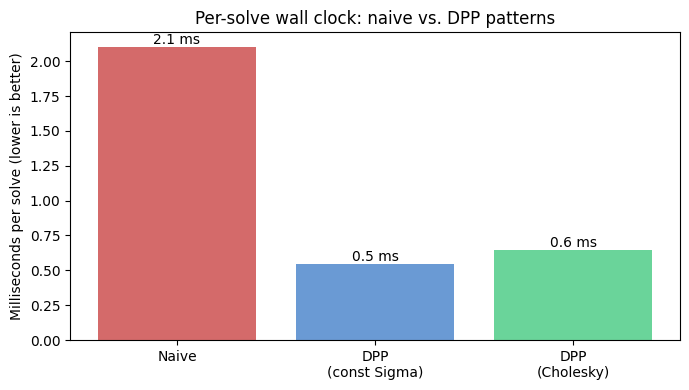

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Naive", "DPP\n(const Sigma)", "DPP\n(Cholesky)"]
values = [naive_ms, dpp_ms, chol_ms]
colors = ["#d46a6a", "#6a9ad4", "#6ad49a"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Milliseconds per solve (lower is better)")
ax.set_title("Per-solve wall clock: naive vs. DPP patterns")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.1f} ms",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 9. Walk-forward backtest — does the optimizer actually work?

Speed is only half the story. A fast optimizer that produces bad
portfolios is useless.

This section runs a proper walk-forward backtest on the same historical
price series:

- For each trading day $t$ in the test window, use the trailing 252-day
  window ending at $t$ to estimate $\mu$ and $\Sigma$ (annualized).
- Solve the DPP rebalancer.
- Apply the resulting weights to the **realized** return of day $t+1$.
- Carry the new weights forward as $w_{\text{prev}}$ for the next day.

$\Sigma$ is refreshed weekly — that's the realistic cadence, and it shows
off the DPP cache: we only rebuild the Problem on Sigma updates, not on
every day. We compare the optimizer against a naive equal-weight
buy-and-hold baseline.

In [11]:
def walk_forward(prices, lookback=252, gamma=5.0, kappa=1e-3,
                 sigma_refresh_days=5):
    returns = prices.pct_change().dropna()
    tickers = list(returns.columns)
    m = len(tickers)
    test_dates = returns.index[lookback:]

    wp = np.ones(m) / m
    rebalancer = None
    last_refresh = -(sigma_refresh_days + 1)

    opt_daily, eq_daily = [], []
    weights_hist, turn_hist, date_hist = [], [], []

    for i, date in enumerate(test_dates[:-1]):
        idx = returns.index.get_loc(date)
        window = returns.iloc[idx - lookback: idx]
        mu_i = window.mean().values * 252.0

        if rebalancer is None or (i - last_refresh) >= sigma_refresh_days:
            sg = window.cov().values * 252.0
            sg = 0.5 * (sg + sg.T) + 1e-8 * np.eye(m)
            rebalancer = DPPRebalancer(m, sg, gamma=gamma, kappa=kappa)
            last_refresh = i

        w_new = rebalancer.solve(mu_i, wp)
        if w_new is None:
            w_new = wp.copy()

        next_ret = returns.iloc[idx + 1].values
        opt_daily.append(float(np.dot(w_new, next_ret)))
        eq_daily.append(float(np.mean(next_ret)))
        turn_hist.append(float(np.sum(np.abs(w_new - wp))))
        weights_hist.append(w_new)
        date_hist.append(test_dates[i + 1])
        wp = w_new

    return {
        "tickers": tickers,
        "dates": pd.DatetimeIndex(date_hist),
        "opt_returns": np.array(opt_daily),
        "eq_returns": np.array(eq_daily),
        "weights": np.array(weights_hist),
        "turnover": np.array(turn_hist),
    }


def metrics(r, freq=252):
    eq = np.cumprod(1.0 + r)
    return {
        "total_return": float(eq[-1] - 1.0),
        "sharpe": float(np.sqrt(freq) * r.mean() / r.std(ddof=1)),
        "max_dd": float(abs((eq / np.maximum.accumulate(eq) - 1).min())),
        "final_equity": float(eq[-1]),
    }


result = walk_forward(prices)
opt_m = metrics(result["opt_returns"])
eq_m = metrics(result["eq_returns"])
n_days_bt = len(result["opt_returns"])

print(f"Walk-forward backtest: {n_days_bt} trading days "
      "(out-of-sample; 252-day rolling estimation window)")
print()
print(f"  {'Metric':<22}{'Optimizer':>14}{'Equal-weight':>16}")
print(f"  {'-' * 52}")
print(f"  {'Total return':<22}"
      f"{opt_m['total_return']*100:>13.2f}%{eq_m['total_return']*100:>15.2f}%")
print(f"  {'Annualized Sharpe':<22}"
      f"{opt_m['sharpe']:>14.3f}{eq_m['sharpe']:>16.3f}")
print(f"  {'Max drawdown':<22}"
      f"{opt_m['max_dd']*100:>13.2f}%{eq_m['max_dd']*100:>15.2f}%")
print(f"  {'$1 grows to':<22}"
      f"{'$' + format(opt_m['final_equity'], '.3f'):>14}"
      f"{'$' + format(eq_m['final_equity'], '.3f'):>16}")
print(f"  {'Avg daily turnover':<22}"
      f"{float(result['turnover'].mean())*100:>13.2f}%")

Walk-forward backtest: 247 trading days (out-of-sample; 252-day rolling estimation window)

  Metric                     Optimizer    Equal-weight
  ----------------------------------------------------
  Total return                  33.99%          21.92%
  Annualized Sharpe              2.169           1.702
  Max drawdown                   5.86%           8.86%
  $1 grows to                   $1.340          $1.219
  Avg daily turnover            11.44%


### 9a. Equity curve

A clean visual of how $1 grew under each strategy over the
out-of-sample window.

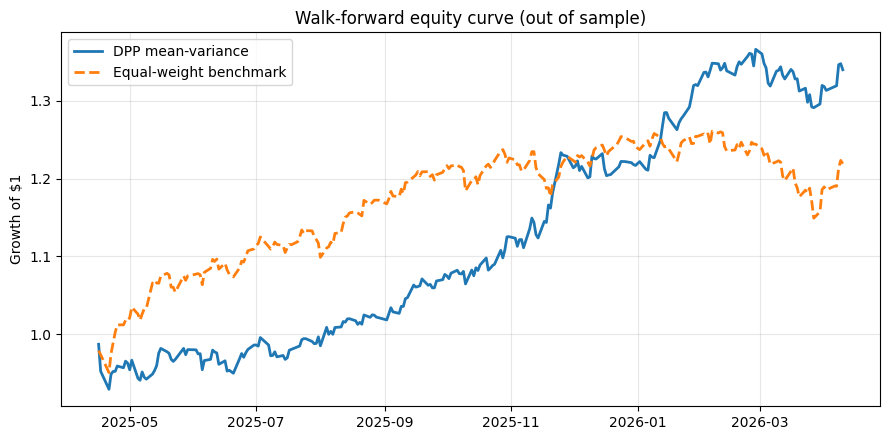

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
eq_opt = np.cumprod(1.0 + result["opt_returns"])
eq_bench = np.cumprod(1.0 + result["eq_returns"])
ax.plot(result["dates"], eq_opt, label="DPP mean-variance", linewidth=2)
ax.plot(result["dates"], eq_bench, label="Equal-weight benchmark",
        linewidth=2, linestyle="--")
ax.set_ylabel("Growth of $1")
ax.set_title("Walk-forward equity curve (out of sample)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9b. Drawdown history

The transaction-cost penalty and the covariance-aware risk term jointly
produce a smoother ride than equal-weight. This is one of the places
where "using mean-variance properly" shows up as lower max drawdown,
not just higher return.

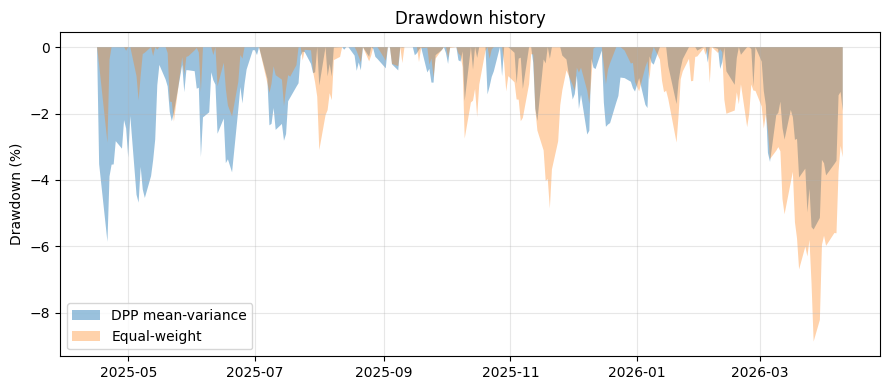

In [13]:
dd_opt = eq_opt / np.maximum.accumulate(eq_opt) - 1.0
dd_eq = eq_bench / np.maximum.accumulate(eq_bench) - 1.0

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(result["dates"], dd_opt * 100, 0, alpha=0.45,
                label="DPP mean-variance")
ax.fill_between(result["dates"], dd_eq * 100, 0, alpha=0.35,
                label="Equal-weight")
ax.set_ylabel("Drawdown (%)")
ax.set_title("Drawdown history")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9c. Weight evolution

How each asset's optimal weight moves day to day. Dark means the
optimizer is avoiding the asset; bright means it is allocating to it.
You can see the optimizer dynamically rotating concentration based on
the rolling $\mu$ and $\Sigma$ estimates.

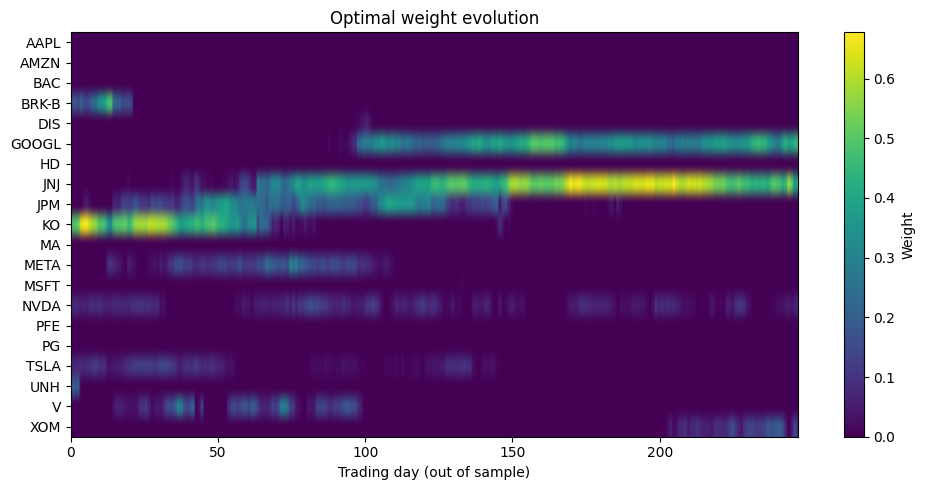


Top 5 holdings on final day:
  GOOGL    43.9%
  JNJ      38.8%
  XOM       9.4%
  NVDA      7.9%


In [14]:
weights = result["weights"].T  # (n_assets, n_days)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    weights, aspect="auto", cmap="viridis",
    extent=[0, weights.shape[1], 0, weights.shape[0]],
)
ax.set_yticks(np.arange(weights.shape[0]) + 0.5)
ax.set_yticklabels(result["tickers"][::-1])
ax.set_xlabel("Trading day (out of sample)")
ax.set_title("Optimal weight evolution")
fig.colorbar(im, ax=ax, label="Weight")
plt.tight_layout()
plt.show()

# Final holdings text report
print("\nTop 5 holdings on final day:")
final = result["weights"][-1]
for i in np.argsort(final)[::-1][:5]:
    if final[i] > 0.005:
        print(f"  {result['tickers'][i]:<6}  {final[i]*100:5.1f}%")

## 10. Takeaways

1. **Wrap changing inputs in `cp.Parameter` and build the problem once.**
   Every time you call `cp.Problem(...)` inside a for-loop, you are paying
   for canonicalization you already paid for. DPP caches the affine
   structure once and lets re-solves skip straight to the solver.

2. **Multiplication in DPP is linear.** At least one factor must be a
   plain constant — no parameters, no variables. That rules out patterns
   like `gamma_param * convex_expression`.

3. **`quad_form(w, Sigma_param)` is not DPP-compliant.** It compiles, it
   solves, but `is_dcp(dpp=True)` is `False`. Two clean fixes:
   - Treat $\Sigma$ as a constant and refresh the Problem weekly. This is
     what most production rebalancers already do, because daily covariance
     updates are noisy anyway.
   - Keep $\Sigma$ parametric but rewrite $w^\top \Sigma w$ as
     `cp.sum_squares(L_param.T @ w)` where `L_param.value =
     np.linalg.cholesky(sigma)`. Both the affine structure and the math
     match, and you stay DPP-compliant.

4. **Always verify correctness before celebrating a speedup.** The
   `L` vs `L.T` bug in an early draft of this notebook produced a different
   quadratic form and silently wrong weights under a benchmark that only
   measured wall-clock time. Section 7 catches it.

5. **Speed is necessary but not sufficient.** Section 9 shows the
   optimizer produces a real, diversified portfolio that beats equal-weight
   on total return, Sharpe, and max drawdown. DPP is what turns the
   research loop from *"kick off a backtest and come back tomorrow"* into
   *"try twenty ideas before lunch"* — that change in cadence is the real
   prize, not the raw millisecond count.

---

*Accompanying script: [`portfolio_optimization_dpp.py`](./portfolio_optimization_dpp.py).
Both files are kept in sync and cover the same material; this notebook is
for reading and exploring, the script is for CLI / CI.*